In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import sqlite3

In [3]:
con = sqlite3.connect(r"C:\Users\sanja\Downloads\password_resources\password_data.sqlite")

In [4]:
data=pd.read_sql_query("SELECT * FROM Users",con)

In [5]:
data.shape

(100000, 3)

In [6]:
data.head(5)

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2
4,4,c443balg,1


In [7]:
data.columns

Index(['index', 'password', 'strength'], dtype='object')

In [8]:
data.drop(["index"],axis = 1 ,inplace = True)

In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data.isnull().any().sum()

np.int64(0)

In [11]:
data.dtypes

password    object
strength     int64
dtype: object

In [12]:
data["strength"].unique()

array([1, 2, 0])

In [13]:
data["password"]

0                      zxe870819
1                   xw46454nr23l
2                      soporte13
3        accounts6000webhost.com
4                       c443balg
                  ...           
99995                 obejofi215
99996                 fmiopvxb64
99997                  czvrbun38
99998                  mymyxe430
99999                glqjhkxb467
Name: password, Length: 100000, dtype: object

In [14]:
type(data["password"][0])

str

In [15]:
data["password"].str.isnumeric()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Name: password, Length: 100000, dtype: bool

In [16]:
data[data["password"].str.isnumeric()]

,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [17]:
data[data["password"].str.isnumeric()].shape

(26, 2)

In [18]:
data[data["password"].str.isupper()]

,password,strength
115,EYT63119,1
273,INSPIRON6,1
338,1A2S3D4F,1
367,13269123A,1
373,YAMAZAKI82,1
...,...,...
99590,V13000993J,1
99692,65925013ABC,1
99784,01EDD055,1
99893,1UPONYOU,1


In [19]:
data[data["password"].str.isalpha()]

,password,strength
267,PomarancaÇ,1
1380,smgodt,0
3198,cuado,0
4560,jelsz,0
6380,demsxp,0
7803,secret,0
9218,caballo,0
11555,mhe,0
11667,kreedo,0
13645,nõmlich,0


In [20]:
data[data["password"].str.isalpha()].shape

(50, 2)

In [21]:
data[data["password"].str.isalnum()]

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
4,c443balg,1
5,16623670p,1
...,...,...
99995,obejofi215,1
99996,fmiopvxb64,1
99997,czvrbun38,1
99998,mymyxe430,1


In [22]:
data[data["password"].str.isalnum()].shape

(97203, 2)

In [23]:
data[data["password"].str.istitle()]

,password,strength
64,Hisanthoshjasika0,2
242,Therockrockbottom72,2
338,1A2S3D4F,1
367,13269123A,1
526,Csicskarozsika1,2
...,...,...
99168,1053815198M,1
99192,Alfranx05122023,2
99375,Kensington1956,2
99590,V13000993J,1


In [24]:
data["password"]

0                      zxe870819
1                   xw46454nr23l
2                      soporte13
3        accounts6000webhost.com
4                       c443balg
                  ...           
99995                 obejofi215
99996                 fmiopvxb64
99997                  czvrbun38
99998                  mymyxe430
99999                glqjhkxb467
Name: password, Length: 100000, dtype: object

In [25]:
import string

In [26]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [27]:
#function is used when task is repeated

In [28]:
def find_semantics(row):
    for char in row:
        if char in string.punctuation:
            return 1

In [29]:
data["password"].apply(find_semantics)

0        NaN
1        NaN
2        NaN
3        1.0
4        NaN
        ... 
99995    NaN
99996    NaN
99997    NaN
99998    NaN
99999    NaN
Name: password, Length: 100000, dtype: float64

In [30]:
data[data["password"].apply(find_semantics)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


In [31]:
data[data["password"].apply(find_semantics)==1].sum()

password    accounts6000webhost.com12463773800+p.r.c.d.g.c...
strength                                                 4130
dtype: object

In [32]:
data[data["password"].apply(find_semantics)==1].apply

<bound method DataFrame.apply of                       password  strength
3      accounts6000webhost.com         2
68                12463773800+         1
98                  p.r.c.d.g.         1
145                  cita-cita         1
180         karolina.susnina0U         2
...                        ...       ...
99748             maiselis.com         1
99845          hosting4meze!@#         2
99954         semista_bakung15         2
99980         halflife2010!LEB         2
99988                lbhtrnjh@         1

[2663 rows x 2 columns]>

In [33]:
data["password_length"] = data["password"].str.len()

In [34]:
data["password_length"]

0         9
1        12
2         9
3        23
4         8
         ..
99995    10
99996    10
99997     9
99998     9
99999    11
Name: password_length, Length: 100000, dtype: int64

In [35]:
password = "Pepsi@123"

In [36]:
[char for char in password if char.islower()]

['e', 'p', 's', 'i']

In [37]:
len([char for char in password if char.islower()])/len(password)

0.4444444444444444

In [38]:
def freq_lowercase(row):
    return len([char for char in row if char.islower()])/len(password)

In [39]:
def freq_uppercase(row):
    return len([char for char in row if char.isupper()])/len(password)

In [40]:
def freq_numerical_case(row):
    return len([char for char in row if char.isdigit()])/len(password)

In [41]:
data["freq_lowercase"] = np.round(data["password"].apply(freq_lowercase),3)
data["freq_uppercase"] = np.round(data["password"].apply(freq_uppercase),3)
data["freq_numerical_case"] = np.round(data["password"].apply(freq_numerical_case),3)

In [42]:
data["freq_lowercase"] 
data["freq_uppercase"]
data["freq_numerical_case"]

0        0.667
1        0.778
2        0.222
3        0.444
4        0.333
         ...  
99995    0.333
99996    0.222
99997    0.222
99998    0.333
99999    0.333
Name: freq_numerical_case, Length: 100000, dtype: float64

In [43]:
data.head(3)

,password,strength,password_length,freq_lowercase,freq_uppercase,freq_numerical_case
0,zxe870819,1,9,0.333,0.0,0.667
1,xw46454nr23l,1,12,0.556,0.0,0.778
2,soporte13,1,9,0.778,0.0,0.222


In [44]:
def freq_special_case(row):
    special_chars = []
    for char in row:
        if not char.isalpha() and not char.isdigit():
            special_chars.append(char)
        
    return len(special_chars) 
    

In [45]:
data["freq_special_case"] = np.round(data["password"].apply(freq_special_case),3)

In [46]:
data.head(3)

,password,strength,password_length,freq_lowercase,freq_uppercase,freq_numerical_case,freq_special_case
0,zxe870819,1,9,0.333,0.0,0.667,0
1,xw46454nr23l,1,12,0.556,0.0,0.778,0
2,soporte13,1,9,0.778,0.0,0.222,0


In [47]:
data["special_case"] = data["freq_special_case"]/data["password_length"]

In [48]:
data.head(3)

,password,strength,password_length,freq_lowercase,freq_uppercase,freq_numerical_case,freq_special_case,special_case
0,zxe870819,1,9,0.333,0.0,0.667,0,0.0
1,xw46454nr23l,1,12,0.556,0.0,0.778,0,0.0
2,soporte13,1,9,0.778,0.0,0.222,0,0.0


In [49]:
data.columns

Index(['password', 'strength', 'password_length', 'freq_lowercase',
       'freq_uppercase', 'freq_numerical_case', 'freq_special_case',
       'special_case'],
      dtype='object')

In [50]:
data[['password_length' , 'strength']].groupby(['strength']).agg(["min","max","mean","median"])

password_length                       
                     min  max       mean median
strength                                       
0                      1    7   6.550947    7.0
1                      8   13   9.611074    9.0
2                     14  220  15.953421   16.0

In [51]:
cols = ['password_length', 'freq_lowercase',
       'freq_uppercase', 'freq_numerical_case', 'freq_special_case',
       'freq_special_case', 'special_case']
for col in cols:
    print(col)
    print(data[[col , 'strength']].groupby(['strength']).agg(["min","max","mean","median"]))
    print('\n')

password_length
         password_length                       
                     min  max       mean median
strength                                       
0                      1    7   6.550947    7.0
1                      8   13   9.611074    9.0
2                     14  220  15.953421   16.0


freq_lowercase
         freq_lowercase                         
                    min     max      mean median
strength                                        
0                   0.0   0.778  0.519182  0.556
1                   0.0   1.333  0.674274  0.667
2                   0.0  12.111  0.757089  0.667


freq_uppercase
         freq_uppercase                        
                    min    max      mean median
strength                                       
0                   0.0  0.667  0.009177  0.000
1                   0.0  1.333  0.008532  0.000
2                   0.0  8.889  0.648563  0.667


freq_numerical_case
         freq_numerical_case                        
     

In [52]:
data.columns

Index(['password', 'strength', 'password_length', 'freq_lowercase',
       'freq_uppercase', 'freq_numerical_case', 'freq_special_case',
       'special_case'],
      dtype='object')

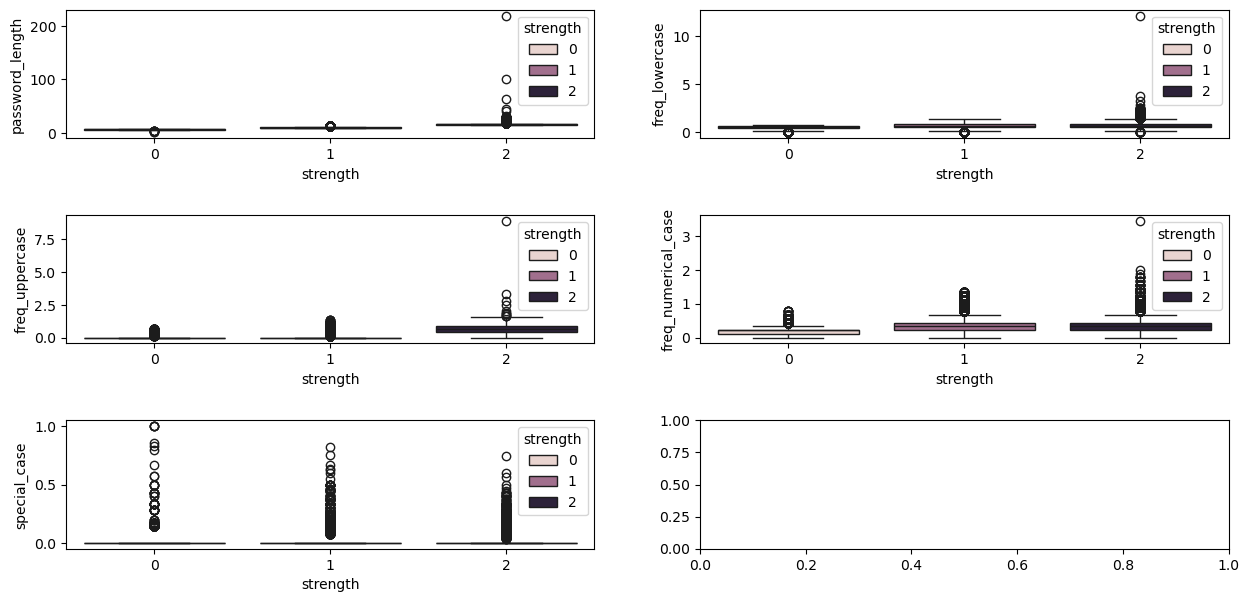

In [53]:
fig ,((ax1,ax2),(ax3,ax4),(ax5,ax6)) = plt.subplots(3,2,figsize=(15,7))

sns.boxplot(x = "strength", y = 'password_length', hue="strength" , ax=ax1,data=data)
sns.boxplot(x = "strength", y = 'freq_lowercase' , hue="strength" , ax=ax2,data=data)
sns.boxplot(x = "strength", y = 'freq_uppercase', hue="strength", ax=ax3,data=data)
sns.boxplot(x = "strength", y = 'freq_numerical_case', hue="strength",ax=ax4,data=data)
sns.boxplot(x = "strength", y = 'special_case', hue="strength" ,ax=ax5,data=data)

plt.subplots_adjust(hspace = 0.6)

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

def get_dist(data, feature):
    fig, axes = plt.subplots(1, 2, figsize=(10,8))

    # Left plot: violin plot
    sns.violinplot(x='strength', y=feature, data=data, ax=axes[0])
    axes[0].set_title(f"Violin Plot of {feature} by Strength")

    # Right plot: KDE distributions for each strength
    sns.kdeplot(data=data[data['strength']==0][feature], color="red", label="0", ax=axes[1])
    sns.kdeplot(data=data[data['strength']==1][feature], color="blue", label="1", ax=axes[1])
    sns.kdeplot(data=data[data['strength']==2][feature], color="yellow", label="2", ax=axes[1])
    axes[1].set_title(f"Distribution of {feature} by Strength")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [55]:
data.columns

Index(['password', 'strength', 'password_length', 'freq_lowercase',
       'freq_uppercase', 'freq_numerical_case', 'freq_special_case',
       'special_case'],
      dtype='object')

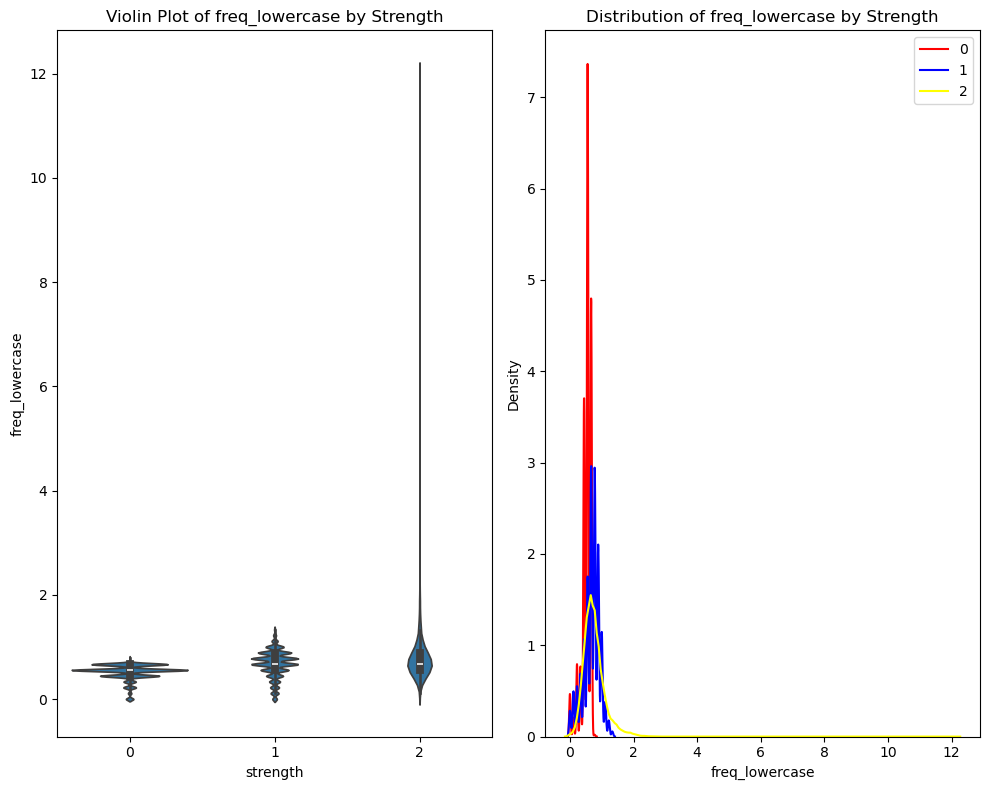

In [56]:
get_dist(data ,'freq_lowercase')

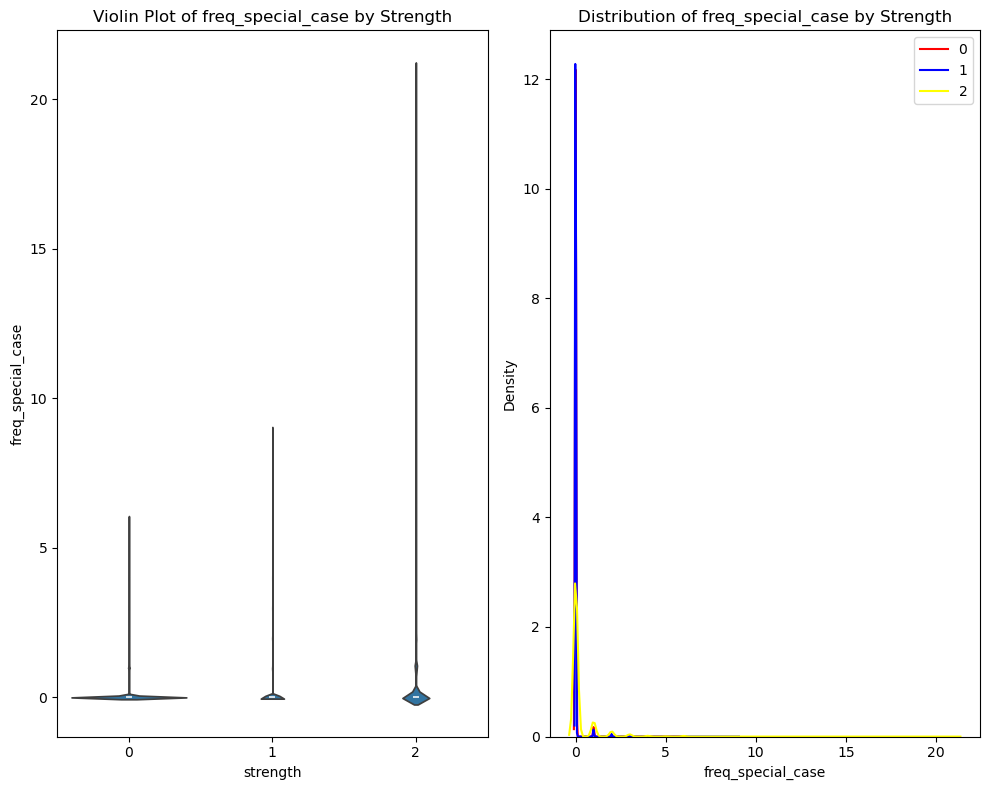

In [57]:
get_dist(data ,'freq_special_case')

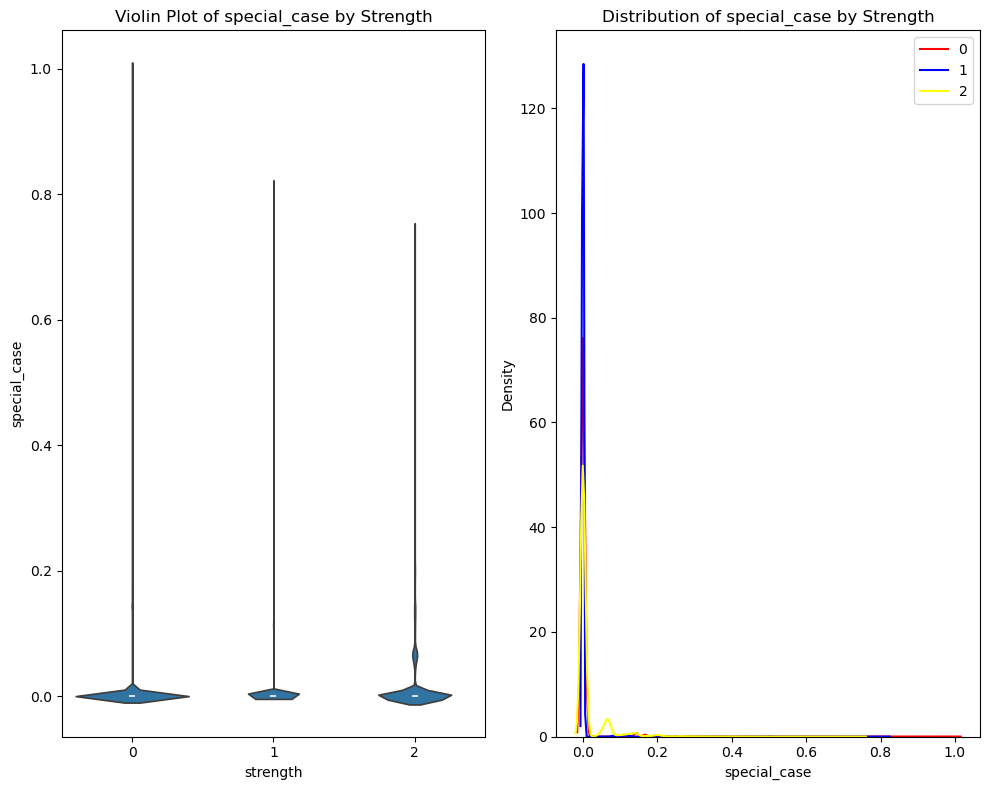

In [58]:
get_dist(data ,'special_case')

In [59]:
data

,password,strength,password_length,freq_lowercase,freq_uppercase,freq_numerical_case,freq_special_case,special_case
0,zxe870819,1,9,0.333,0.0,0.667,0,0.000000
1,xw46454nr23l,1,12,0.556,0.0,0.778,0,0.000000
2,soporte13,1,9,0.778,0.0,0.222,0,0.000000
3,accounts6000webhost.com,2,23,2.000,0.0,0.444,1,0.043478
4,c443balg,1,8,0.556,0.0,0.333,0,0.000000
...,...,...,...,...,...,...,...,...
99995,obejofi215,1,10,0.778,0.0,0.333,0,0.000000
99996,fmiopvxb64,1,10,0.889,0.0,0.222,0,0.000000
99997,czvrbun38,1,9,0.778,0.0,0.222,0,0.000000
99998,mymyxe430,1,9,0.667,0.0,0.333,0,0.000000


In [60]:
dataframe = data.sample(frac = 1)

In [61]:
dataframe

,password,strength,password_length,freq_lowercase,freq_uppercase,freq_numerical_case,freq_special_case,special_case
84253,j20960244,1,9,0.111,0.0,0.889,0,0.0
40806,catchme1,1,8,0.778,0.0,0.111,0,0.0
66962,mautauaja7718,1,13,1.000,0.0,0.444,0,0.0
2238,jucanaga21,1,10,0.889,0.0,0.222,0,0.0
59876,nobil631,1,8,0.556,0.0,0.333,0,0.0
...,...,...,...,...,...,...,...,...
59325,deivuxas1,1,9,0.889,0.0,0.111,0,0.0
15610,graf77,0,6,0.444,0.0,0.222,0,0.0
76343,sudpack6,1,8,0.778,0.0,0.111,0,0.0
30662,wovutu964,1,9,0.667,0.0,0.333,0,0.0


In [62]:
x = list(dataframe["password"])

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [64]:
vectorizer = TfidfVectorizer(analyzer = "char")

In [65]:
X = vectorizer.fit_transform(x)

In [66]:
X.shape

(100000, 99)

In [67]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 842571 stored elements and shape (100000, 99)>

In [68]:
X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100000, 99))

In [69]:
len(vectorizer.get_feature_names_out())

99

In [70]:
df2 = pd.DataFrame(X.toarray() , columns =vectorizer.get_feature_names_out() )

In [71]:
df2

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
data.columns

Index(['password', 'strength', 'password_length', 'freq_lowercase',
       'freq_uppercase', 'freq_numerical_case', 'freq_special_case',
       'special_case'],
      dtype='object')

In [73]:
df2["password_length"] = data['password_length']
df2["freq_lowercase"] = data['freq_lowercase']

In [74]:
df2

,,,,,,,,,!,#,...,õ,ö,÷,ú,ü,ý,þ,›,password_length,freq_lowercase
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.333
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0.556
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2.000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.778
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.889
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.667


In [75]:
y=dataframe["strength"]

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(df2,y,test_size = 0.20,random_state=42)

In [78]:
X_train.shape

(80000, 101)

In [79]:
y_train.shape

(80000,)

In [80]:
X_test.shape

(20000, 101)

In [81]:
y_test.shape

(20000,)

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
clf = LogisticRegression( multi_class="multinomial")

In [84]:
clf.fit(X_train,y_train)

C:\Users\sanja\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sanja\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [85]:
y_pred = clf.predict(X_test)

In [86]:
y_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(20000,))

In [87]:
from collections import Counter

In [88]:
Counter(y_pred)

Counter({np.int64(1): 16624, np.int64(2): 1880, np.int64(0): 1496})

In [89]:
password = "%@123abcd"

In [90]:
sample_array = np.array([password])

In [91]:
sample_matrix = vectorizer.transform(sample_array)

In [92]:
sample_matrix.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.71897928, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.14344586, 0.1659599 , 0.18587581, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.48741481, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.13814351, 0.23158091, 0.21637656,
        0.20807263, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [93]:
sample_matrix.toarray().shape

(1, 99)

In [94]:
password

'%@123abcd'

In [95]:
len(password)

9

In [96]:
[char for char in password if char.islower()]

['a', 'b', 'c', 'd']

In [97]:
len([char for char in password if char.islower()])

4

In [98]:
len([char for char in password if char.islower()])/len(password)

0.4444444444444444

In [99]:
np.append(sample_matrix.toarray() , (9,0.44)).shape

(101,)

In [100]:
np.append(sample_matrix.toarray() , (9,0.44)).reshape(1,101)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.71897928, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.14344586, 0.1659599 , 0.18587581, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.48741481, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.13814351, 0.23158091, 0.21637656,
        0.20807263, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [101]:
np.append(sample_matrix.toarray() , (9,0.44)).reshape(1,101).shape

(1, 101)

In [102]:
new_matrix = np.append(sample_matrix.toarray() , (9,0.44)).reshape(1,101)

In [103]:
clf.predict(new_matrix)

C:\Users\sanja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [104]:
def predict():
    password = input("Enter a password : ")
    sample_array = np.array([password])
    sample_matrix = vectorizer.transform(sample_array)

    length_pass = len(password)
    length_normalised_lowercase = len([char for char in password if char.islower()])/len(password)

    new_matrix2 = np.append(sample_matrix.toarray() ,(length_pass , length_normalised_lowercase)).reshape(1,101)
    result = clf.predict(new_matrix2)

    if result == 0:
        return "Password is weak"
    elif result == 1:
        return "Password is normal"
    else:
        return "Password is strong"

In [107]:
predict()

Enter a password :  Sp5243120_@#


C:\Users\sanja\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


'Password is strong'